In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [7]:
import os

print(os.listdir())

['.config', 'fear_greed_index (1).csv', 'historical_data (1).csv', 'sample_data']


In [8]:
trader = pd.read_csv("historical_data (1).csv")
sentiment = pd.read_csv("fear_greed_index (1).csv")

In [9]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [10]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [11]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [12]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [13]:
print("Trader Dataset Shape:", trader.shape)
print("Sentiment Dataset Shape:", sentiment.shape)

Trader Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)


In [14]:
print("Trader Missing Values")
print(trader.isnull().sum())

print("\nSentiment Missing Values")
print(sentiment.isnull().sum())

Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [15]:
print("Trader Duplicates:", trader.duplicated().sum())
print("Sentiment Duplicates:", sentiment.duplicated().sum())

Trader Duplicates: 0
Sentiment Duplicates: 0


In [17]:
trader['Date'] = pd.to_datetime(
    trader['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
).dt.date

In [18]:
print(sentiment.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [19]:
trader['Date'] = pd.to_datetime(
    trader['Timestamp IST'],
    dayfirst=True,
    format='mixed'
).dt.date

In [20]:
sentiment['Date'] = pd.to_datetime(sentiment['date']).dt.date

In [21]:
merged = pd.merge(
    trader,
    sentiment[['Date', 'classification', 'value']],
    on='Date',
    how='left'
)

In [22]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [24]:
print(merged[['Date', 'classification', 'value']].head())

         Date classification  value
0  2024-12-02  Extreme Greed   80.0
1  2024-12-02  Extreme Greed   80.0
2  2024-12-02  Extreme Greed   80.0
3  2024-12-02  Extreme Greed   80.0
4  2024-12-02  Extreme Greed   80.0


In [25]:
print("Trader Date Range:")
print(trader['Date'].min(), "to", trader['Date'].max())

print("\nSentiment Date Range:")
print(sentiment['Date'].min(), "to", sentiment['Date'].max())

Trader Date Range:
2023-05-01 to 2025-05-01

Sentiment Date Range:
2018-02-01 to 2025-05-02


In [26]:
print(merged['classification'].isnull().sum())

6


In [27]:
merged['Profit'] = merged['Closed PnL'].apply(lambda x: 1 if x > 0 else 0)

In [28]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean().reset_index()
print(avg_pnl)

  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


In [29]:
win_rate = merged.groupby('classification')['Profit'].mean() * 100
print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Profit, dtype: float64


In [30]:
trade_count = merged.groupby('classification').size().reset_index(name='Trades')
print(trade_count)

  classification  Trades
0   Extreme Fear   21400
1  Extreme Greed   39992
2           Fear   61837
3          Greed   50303
4        Neutral   37686


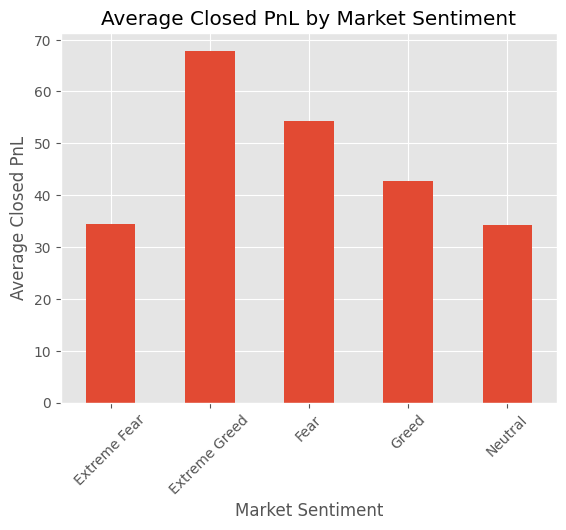

In [31]:
import matplotlib.pyplot as plt

avg_pnl.plot(kind='bar', x='classification', y='Closed PnL', legend=False)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.show()

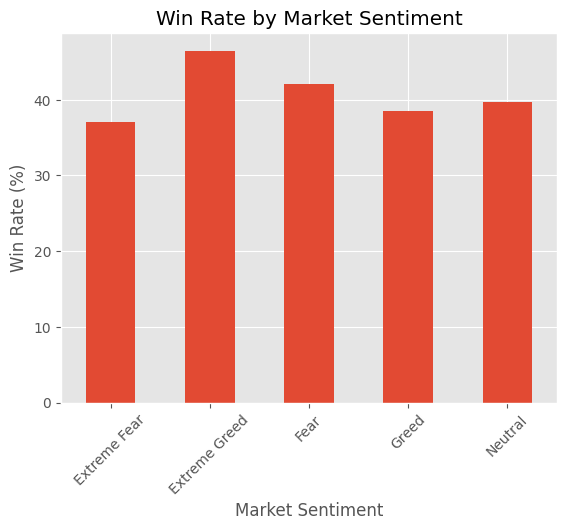

In [32]:
win_rate = merged.groupby('classification')['Profit'].mean() * 100

win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)

plt.show()

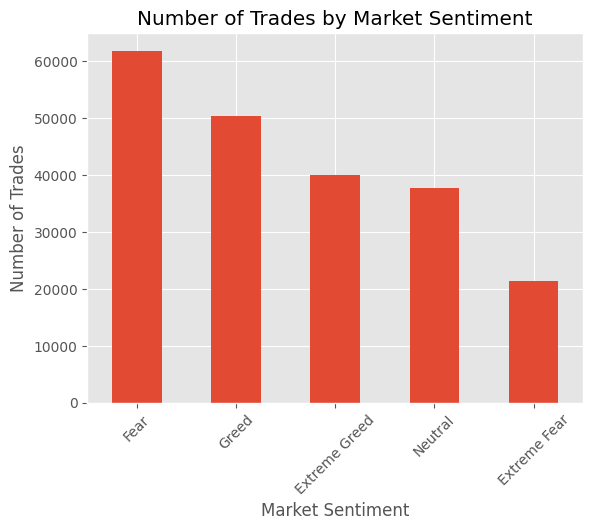

In [33]:
trade_count = merged['classification'].value_counts()

trade_count.plot(kind='bar')

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

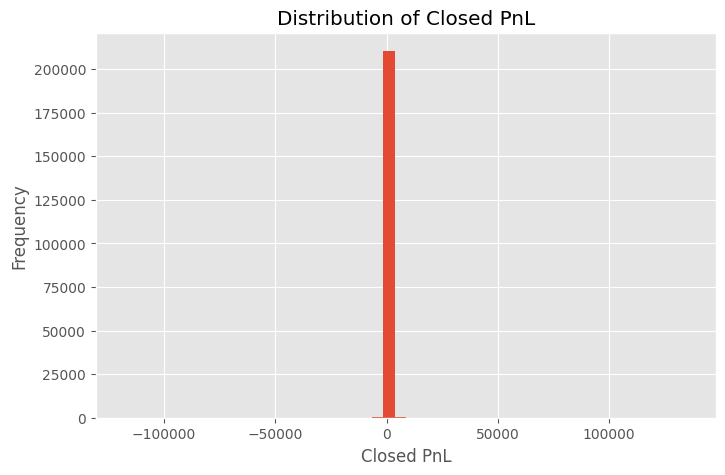

In [34]:
plt.figure(figsize=(8,5))

plt.hist(merged['Closed PnL'], bins=50)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.show()

In [35]:
plt.savefig("avg_pnl.png")

<Figure size 640x480 with 0 Axes>

In [36]:
plt.savefig("win_rate.png")
plt.show()

<Figure size 640x480 with 0 Axes>

In [37]:
print("\nAverage PnL")
print(avg_pnl)

print("\nWin Rate")
print(win_rate)

print("\nTrade Count")
print(trade_count)


Average PnL
  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718

Win Rate
classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Profit, dtype: float64

Trade Count
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [38]:
# Average leverage by account
leverage = merged.groupby('Account')['Start Position'].mean().reset_index()

# Median leverage
median_leverage = leverage['Start Position'].median()

# Segment traders
leverage['Trader Segment'] = leverage['Start Position'].apply(
    lambda x: 'High Leverage' if x > median_leverage else 'Low Leverage'
)

print(leverage.head())

                                      Account  Start Position Trader Segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012    -1247.334684   Low Leverage
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    11181.808655  High Leverage
2  0x271b280974205ca63b716753467d5a371de622ab   -10248.195171   Low Leverage
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    17817.982104  High Leverage
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   472411.528070  High Leverage


In [39]:
# Merge trader segments back into the main dataset
merged = merged.merge(
    leverage[['Account', 'Trader Segment']],
    on='Account',
    how='left'
)

# Average PnL by Trader Segment
segment_pnl = merged.groupby('Trader Segment')['Closed PnL'].mean()

print(segment_pnl)

Trader Segment
High Leverage    50.153193
Low Leverage     45.980561
Name: Closed PnL, dtype: float64


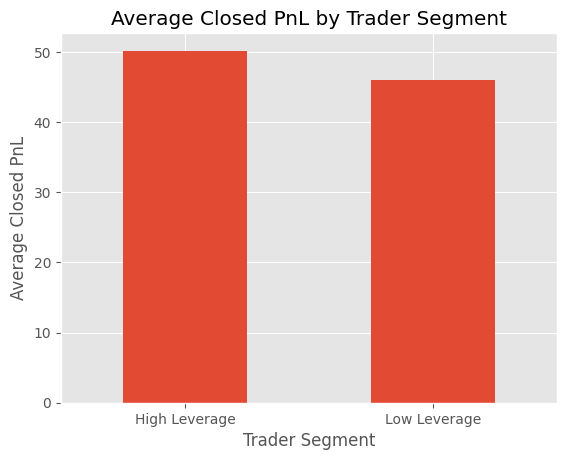

In [40]:
segment_pnl.plot(kind='bar')

plt.title("Average Closed PnL by Trader Segment")
plt.xlabel("Trader Segment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=0)

plt.show()

In [41]:
summary = merged.groupby('classification').agg({
    'Closed PnL':'mean',
    'Profit':'mean',
    'Account':'count'
})

summary.rename(columns={
    'Closed PnL':'Average PnL',
    'Profit':'Win Rate',
    'Account':'Trade Count'
}, inplace=True)

summary['Win Rate'] = summary['Win Rate'] * 100

print(summary)

                Average PnL   Win Rate  Trade Count
classification                                     
Extreme Fear      34.537862  37.060748        21400
Extreme Greed     67.892861  46.494299        39992
Fear              54.290400  42.076750        61837
Greed             42.743559  38.482794        50303
Neutral           34.307718  39.699093        37686


# Trader Performance vs Market Sentiment Analysis

## Objective
This project analyzes the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance on Hyperliquid.

## Datasets
1. Historical Trader Data
2. Bitcoin Fear & Greed Index

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab

## Methodology
- Data Cleaning
- Date Conversion
- Dataset Merging
- Exploratory Data Analysis
- Trader Segmentation
- Performance Analysis

## Key Findings
- Extreme Greed had the highest Average PnL (67.89).
- Fear recorded the highest trading activity (61,837 trades).
- Extreme Greed achieved the highest win rate (46.49%).
- High Leverage traders showed slightly higher average PnL than Low Leverage traders.

## Strategy Recommendations
- Increase position size cautiously during Extreme Greed.
- Apply stricter risk management during Fear periods.

## Conclusion
Market sentiment significantly influences trader behavior and profitability. Incorporating sentiment into trading strategies can improve decision-making and risk management.